# Spectral fitting example (NGC 4151)

This notebook fits NGC 4151 with the hybrid FITS-normalized catalog written by
`Source_catalog_generator_comp_fit_norm.ipynb`. The observed mock-data
histogram is constructed explicitly as:

`total DC4 background + the 21 target-GTI-binned catalog sources`.

Choose exactly one NGC 4151 spectral hypothesis below: a cutoff power law
(`cpl`) or a cutoff power law plus a power-law tail (`cpl+pl`). Only the
selected hypothesis is built and fitted; the notebook creates one likelihood
and performs one fit.

The likelihood receives the total DC4 background alone as its background
template. All 21 source contributions are modeled through the source catalog
and forward-folded response, rather than being counted twice.

In [1]:
from pathlib import Path
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from astromodels import (
    Cutoff_powerlaw,
    Parameter,
    PointSource,
    Powerlaw,
    load_model,
)
from histpy import Histogram
from threeML import DataList, JointLikelihood

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood
from cosipy.threeml.custom_functions import SpecFromDat  # noqa: F401

%matplotlib inline

11:59:29 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=511351;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=186164;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=153006;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=720194;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=405187;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=781800;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

11:59:30 INFO      Starting 3ML!                                                                     ]8;id=420206;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=316088;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=573156;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=947801;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=71436;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=451075;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=242954;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=608814;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=418494;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=995395;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=661947;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=172770;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=553215;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=614885;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Construct the mock data and load the response

The total-background histogram and all 21 source histograms use the same
60° NGC 4151 pointing cut. The source files are loaded from the cache written
by `Source_catalog_generator_comp_fit_norm.ipynb`; native FITS events are not
rebinned in this fitting notebook.

In [2]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)

DC4_ROOT_CANDIDATES = [
    Path(
        "/Users/parshadkp/Library/CloudStorage/"
        "OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files"
    ),
    Path(
        "/Users/parshadkp/Library/CloudStorage/"
        "OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files"
    ),
]
dc4_files_root = next(
    (candidate for candidate in DC4_ROOT_CANDIDATES if candidate.exists()),
    None,
)
if dc4_files_root is None:
    raise FileNotFoundError(
        "Could not find DC4_Files in any configured location: "
        f"{DC4_ROOT_CANDIDATES}"
    )

background_path = (
    dc4_files_root
    / "Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
source_binned_directory = (
    dc4_files_root
    / "DC4_Sources/DC4_Binned/NGC4151_Cut"
)

# Use an explicit mapping so an unrelated HDF5 file placed in the directory
# cannot silently become part of the mock data.
SOURCE_BINNED_FILENAMES = {
    "cyg_x1_hard": (
        "cygX1_hard_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "crab": (
        "Crab_DC4_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "one_e_1740_compow": (
        "1E1740_compow_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "grs_1758_258": (
        "GRS1758_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "cena": (
        "CenA_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "four_c_71p07": (
        "4C71p07_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "four_c_21p35_noflare": (
        "4C21p35_noflare_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "four_c_21p35_flare": (
        "4C21p35_flare_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "maxi_j1820": (
        "MAXIJ1820_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "maxi_j1348": (
        "MAXIJ1348_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "three_c_454p3_low": (
        "3C454p3_low_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "three_c_454p3_high": (
        "3C454p3_high_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "ngc1068": (
        "NGC_1068_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "ngc4151": (
        "NGC_4151_ec200_0p30_DC4_COSI_cpl_pl_time_cut_in_fov.hdf5"
    ),
    "cyg_x3": (
        "cygX3_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "psr_b1259": (
        "PSRB1259_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "one_rxs_j170849": (
        "1RXSJ170849_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "generic_magnetar": (
        "magnetar2_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "ls_5039": (
        "LS5039_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "psr_j1846": (
        "PSRJ1846_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
    "co_nova_continuum": (
        "nova_co_continuum_3months_binned_data_filtered_with_SAAcut_"
        "NGC4151_Cut.hdf5"
    ),
}
source_binned_paths = {
    source_name: source_binned_directory / filename
    for source_name, filename in SOURCE_BINNED_FILENAMES.items()
}
if len(source_binned_paths) != 21:
    raise RuntimeError(
        f"Expected 21 source files, found {len(source_binned_paths)}"
    )

orientation_path = (
    dc4_files_root
    / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)
response_path = (
    dc4_files_root
    / "ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
agn_config = notebook_dir / "agn.yaml"
source_catalog_path = (
    notebook_dir
    / "source_catalog_DC4_21sources_NGC4151_GTI_fit_norm.yaml"
)

# Eight repetitions of the three-month simulation represent 24 months.
# This scales data, background counts, source counts, and response livetime
# together. It does not rescale any frozen source-catalog parameter.
exposure_multiplier = 1
exposure_months = 3 * exposure_multiplier

for path in (
    background_path,
    source_binned_directory,
    orientation_path,
    response_path,
    agn_config,
    source_catalog_path,
    *source_binned_paths.values(),
):
    if not path.exists():
        raise FileNotFoundError(path)

print("Using DC4 files from:", dc4_files_root)
print("Using source catalog:", source_catalog_path.name)
print("Using binned source directory:", source_binned_directory)
print("Number of binned source files:", len(source_binned_paths))

Using DC4 files from: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files
Using source catalog: source_catalog_DC4_21sources_NGC4151_GTI_fit_norm.yaml
Using binned source directory: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_Sources/DC4_Binned/NGC4151_Cut
Number of binned source files: 21


Apply the 60° orientation/FOV cut for NGC 4151, including Earth occultation.
The resulting ordinary filtered history is used for every catalog source.
Variable-source durations are already absorbed into their GTI-fitted frozen
normalizations.


In [3]:
source_l = 155.07 * u.deg
source_b = 75.06 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

max_offaxis = 60 * u.deg
earth_occ = True

sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

# Repeat the selected pointing history by scaling interval livetimes only.
# The attitude and Earth-occultation selection remain unchanged.
sc_orientation = SpacecraftHistory(
    sc_orientation_cut.obstime,
    sc_orientation_cut.attitude,
    sc_orientation_cut.location,
    livetime=sc_orientation_cut.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_cut.cache_earth_occ

full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
fov_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
scaled_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Three-month FOV-cut livetime: {fov_livetime:,.1f} s")
print(f"Scaled {exposure_months}-month livetime: {scaled_livetime:,.1f} s")
print(f"FOV/full livetime fraction: {fov_livetime / full_livetime:.4f}")


Full orientation livetime: 6,579,555.0 s
Three-month FOV-cut livetime: 980,415.0 s
Scaled 3-month livetime: 980,415.0 s
FOV/full livetime fraction: 0.1490


Construct the observed mock data by adding the total DC4 background to the
21 separately binned source histograms. The component table is a direct
bookkeeping check: its final row must equal the count total supplied to the
likelihood.

`exposure_multiplier` scales data, background counts, source counts, and
response livetime together. It does not change any source-catalog parameter.

In [4]:
def histogram_total(histogram):
    return float(
        histogram.project("Em").to_dense(copy=False).contents.sum()
    )


total_background_three_month = Histogram.open(background_path).project(
    "Em", "Phi", "PsiChi"
)

# HistPy sparse += sparse is not reliable in all supported versions. The
# analysis space has only 10 x 30 x 768 bins, so use a dense accumulator.
all_sources_three_month = Histogram(
    total_background_three_month.axes,
    sparse=False,
)
source_count_rows = []

for source_name, source_path in source_binned_paths.items():
    source_histogram = Histogram.open(source_path).project(
        "Em", "Phi", "PsiChi"
    )
    if source_histogram.axes != total_background_three_month.axes:
        raise ValueError(
            f"{source_name}: binned-source axes do not match the "
            "total-background axes"
        )

    source_counts = histogram_total(source_histogram)
    all_sources_three_month += source_histogram
    source_count_rows.append(
        {
            "source": source_name,
            "3-month NGC 4151 GTI counts": source_counts,
            "file": source_path.name,
        }
    )

source_count_table = (
    pd.DataFrame(source_count_rows)
    .sort_values("3-month NGC 4151 GTI counts", ascending=False)
    .reset_index(drop=True)
)
display(
    source_count_table.style.format(
        {"3-month NGC 4151 GTI counts": "{:,.1f}"}
    )
)

# Observed mock data = instrumental background + all 21 catalog sources.
data_three_month = total_background_three_month.to_dense(copy=True)
data_three_month += all_sources_three_month
data_hist = data_three_month * exposure_multiplier

# The likelihood background remains instrumental background only. The source
# catalog supplies the 21 source expectations through the folded response.
total_bkg = total_background_three_month * exposure_multiplier
total_bkg += sys.float_info.min
bkg_dist = {"total_bkg": total_bkg}

background_counts_three_month = histogram_total(
    total_background_three_month
)
source_counts_three_month = histogram_total(all_sources_three_month)
mock_counts_three_month = histogram_total(data_three_month)
expected_mock_counts = (
    background_counts_three_month + source_counts_three_month
)
if not np.isclose(mock_counts_three_month, expected_mock_counts):
    raise RuntimeError(
        "Mock-data bookkeeping failed: background + sources does not "
        "equal the constructed data histogram"
    )

component_count_table = pd.DataFrame(
    [
        {
            "component": "Total DC4 background",
            "3-month NGC 4151 GTI counts": background_counts_three_month,
        },
        {
            "component": "All 21 binned sources",
            "3-month NGC 4151 GTI counts": source_counts_three_month,
        },
        {
            "component": "Constructed mock data",
            "3-month NGC 4151 GTI counts": mock_counts_three_month,
        },
    ]
)
component_count_table[f"{exposure_months}-month counts"] = (
    component_count_table["3-month NGC 4151 GTI counts"]
    * exposure_multiplier
)
display(
    component_count_table.style.format(
        {
            "3-month NGC 4151 GTI counts": "{:,.1f}",
            f"{exposure_months}-month counts": "{:,.1f}",
        }
    )
)

background_rate_initial = (
    histogram_total(total_bkg) / scaled_livetime
)
print(f"Initial instrumental-background rate: {background_rate_initial:.6g} Hz")
print(
    f"Constructed {exposure_months}-month mock-data counts: "
    f"{histogram_total(data_hist):,.1f}"
)

,source,3-month NGC 4151 GTI counts,file
0,crab,"599,435.0",Crab_DC4_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
1,four_c_21p35_flare,"165,892.0",4C21p35_flare_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
2,ngc4151,"76,103.4",NGC_4151_ec200_0p30_DC4_COSI_cpl_pl_time_cut_in_fov.hdf5
3,maxi_j1820,"45,875.0",MAXIJ1820_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
4,four_c_71p07,"36,917.0",4C71p07_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
5,four_c_21p35_noflare,"19,422.0",4C21p35_noflare_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
6,cena,"18,066.0",CenA_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
7,cyg_x1_hard,"10,902.0",cygX1_hard_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
8,one_e_1740_compow,"5,934.0",1E1740_compow_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5
9,generic_magnetar,"4,558.0",magnetar2_3months_binned_data_filtered_with_SAAcut_NGC4151_Cut.hdf5


,component,3-month NGC 4151 GTI counts,3-month counts
0,Total DC4 background,"25,071,034.0","25,071,034.0"
1,All 21 binned sources,"990,821.4","990,821.4"
2,Constructed mock data,"26,061,855.4","26,061,855.4"


Initial instrumental-background rate: 25.5719 Hz
Constructed 3-month mock-data counts: 26,061,855.4


Open the continuum response.

In [5]:
dr = FullDetectorResponse.open(str(response_path))

## Perform the spectral fit

Load the fixed 21-source catalog and create the COSI 3ML plugin. The
observed histogram already contains the binned counts from those same 21
sources, while `FreeNormBinnedBackground` contains only the total DC4
instrumental-background template. The catalog source models are forward folded
through the ordinary NGC 4151 GTI response to predict their portion of the
observed counts.

No source-specific light-curve response is constructed because the frozen
variable-source amplitudes already reproduce their native FITS counts inside
this GTI.

The YAML preserves the injected polarization of all four Crab components. If
the selected detector response has no `Pol` axis, the notebook sets the
in-memory polarization degrees to zero and reports the unpolarized
approximation.

In [6]:
model = load_model(source_catalog_path)
assert len(model.free_parameters) == 0
if "ngc4151" not in model.sources:
    raise RuntimeError("The catalog must contain ngc4151")
if set(model.sources) != set(source_binned_paths):
    raise RuntimeError(
        "Catalog/source-file mismatch. "
        f"Catalog only: {sorted(set(model.sources) - set(source_binned_paths))}; "
        f"files only: {sorted(set(source_binned_paths) - set(model.sources))}"
    )

crab_polarization_supported = "Pol" in dr.axes.labels
if "crab" in model.sources and not crab_polarization_supported:
    for component in model.crab.components.values():
        component.polarization.degree.value = 0.0
    print(
        "WARNING: The detector response has no Pol axis. "
        "Using the four-component Crab spectrum with zero polarization."
    )

data = EmCDSBinnedData(data_hist)
bkg = FreeNormBinnedBackground(
    bkg_dist,
    sc_history=sc_orientation,
    copy=False,
)
instrument_response = BinnedInstrumentResponse(dr, data)

psr = BinnedThreeMLPointSourceResponse(
    data=data,
    instrument_response=instrument_response,
    sc_history=sc_orientation,
    energy_axis=dr.axes["Ei"],
    polarization_axis=(
        dr.axes["Pol"] if "Pol" in dr.axes.labels else None
    ),
    nside=2 * data.axes["PsiChi"].nside,
)
response = BinnedThreeMLModelFolding(
    data=data,
    point_source_response=psr,
)
like_fun = PoissonLikelihood(data, response, bkg)
cosi = ThreeMLPluginInterface("cosi", like_fun, response, bkg)

for bkg_label in bkg_dist:
    cosi.bkg_parameter[bkg_label] = Parameter(
        bkg_label,
        background_rate_initial,
        min_value=0.0,
        max_value=50.0,
        delta=max(0.05 * background_rate_initial, 1e-6),
        unit=u.Hz,
    )

print(f"Loaded fixed catalog with {len(model.sources)} entries.")
print("Verified one binned source file for every catalog entry.")
print("All catalog sources use the ordinary NGC 4151 GTI response.")
print("The fitted background template contains no source histograms.")


Loaded fixed catalog with 21 entries.
Verified one binned source file for every catalog entry.
All catalog sources use the ordinary NGC 4151 GTI response.
The fitted background template contains no source histograms.


## Choose one NGC 4151 fit

The two short code cells below are the fit switches. Leave exactly one
`SELECTED_FIT_MODELS.append(...)` line uncommented:

- `"cpl+pl"`: cutoff power law plus non-thermal power-law tail.
- `"cpl"`: cutoff power law only.

The default is `"cpl+pl"`. To switch, comment its line and uncomment the CPL
line. The validation in the model cell stops with a clear error if zero or two
choices are active.

In [7]:
# Reset the selector so rerunning these cells in the same kernel is safe.
SELECTED_FIT_MODELS = []

In [8]:
# # CPL + power-law tail fit (active by default).
# SELECTED_FIT_MODELS.append("cpl+pl")

In [9]:
# # CPL-only fit. Uncomment the next line after commenting the CPL+PL line.
SELECTED_FIT_MODELS.append("cpl")

Configure only the selected NGC 4151 spectral hypothesis. Every nuisance
source and all of its parameters remain fixed.

- The CPL+PL fit frees thermal normalization, cutoff energy, tail index, and
  the linked tail-to-thermal normalization ratio.
- The CPL fit frees normalization, photon index, and cutoff energy.

In [10]:
if len(SELECTED_FIT_MODELS) != 1:
    raise RuntimeError(
        "Select exactly one fit by leaving one selector cell uncommented. "
        f"Active choices: {SELECTED_FIT_MODELS}"
    )
FIT_MODEL = SELECTED_FIT_MODELS[0]
if FIT_MODEL not in {"cpl", "cpl+pl"}:
    raise ValueError(f"Unknown FIT_MODEL: {FIT_MODEL!r}")

D = 0.30

# The injected CPL+PL spectrum is the source used to create the NGC 4151
# histogram. It remains the reference curve for either fitted hypothesis.
spectrum_inj_cpl = Cutoff_powerlaw()
spectrum_inj_cpl.K.value = 0.15
spectrum_inj_cpl.piv.value = 1.0
spectrum_inj_cpl.xc.value = 200.0
spectrum_inj_cpl.index.value = -1.75
spectrum_inj_cpl.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_cpl.piv.unit = u.keV
spectrum_inj_cpl.xc.unit = u.keV

spectrum_inj_tail = Powerlaw()
spectrum_inj_tail.K.value = (
    D * spectrum_inj_cpl.evaluate_at(200.0)
)
spectrum_inj_tail.piv.value = 200.0
spectrum_inj_tail.index.value = -3.8
spectrum_inj_tail.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_tail.piv.unit = u.keV
spectrum_inj = spectrum_inj_cpl + spectrum_inj_tail

assert len(model.free_parameters) == 0

if FIT_MODEL == "cpl+pl":
    fit_model_label = "CPL + PL"
    ngc4151_fit = model.ngc4151.spectrum.main.composite

    ngc4151_fit.K_1.min_value = 1e-8
    ngc4151_fit.K_1.max_value = 1e-2
    ngc4151_fit.K_1.fix = False

    ngc4151_fit.xc_1.min_value = 100.0
    ngc4151_fit.xc_1.max_value = 10000.0
    ngc4151_fit.xc_1.fix = False

    ngc4151_fit.index_2.min_value = -5.0
    ngc4151_fit.index_2.max_value = -2.0
    ngc4151_fit.index_2.fix = False

    # K_2 is linked to K_1 in the catalog. Free the link coefficient so the
    # normalization ratio at the common 200 keV reference can be fitted.
    tail_link = ngc4151_fit.K_2.auxiliary_variable[1]
    tail_link.a.fix = True
    tail_link.b.fix = False
    tail_link.b.min_value = 0.0
    tail_link.b.max_value = 1.0
    tail_link.b.delta = max(0.1 * tail_link.b.value, 1e-4)

    expected_free_parameters = {
        "ngc4151.spectrum.main.composite.K_1",
        "ngc4151.spectrum.main.composite.xc_1",
        "ngc4151.spectrum.main.composite.K_2.Line.b",
        "ngc4151.spectrum.main.composite.index_2",
    }
else:
    fit_model_label = "CPL"
    catalog_source = model.ngc4151
    catalog_shape = catalog_source.spectrum.main.shape

    ngc4151_cpl = Cutoff_powerlaw()
    ngc4151_cpl.K.value = catalog_shape.K_1.value
    ngc4151_cpl.K.unit = catalog_shape.K_1.unit
    ngc4151_cpl.piv.value = catalog_shape.piv_1.value
    ngc4151_cpl.piv.unit = catalog_shape.piv_1.unit
    ngc4151_cpl.index.value = catalog_shape.index_1.value
    ngc4151_cpl.xc.value = catalog_shape.xc_1.value
    ngc4151_cpl.xc.unit = catalog_shape.xc_1.unit

    ngc4151_cpl_source = PointSource(
        "ngc4151",
        l=catalog_source.position.l.value,
        b=catalog_source.position.b.value,
        spectral_shape=ngc4151_cpl,
    )
    model.remove_source("ngc4151")
    model.add_source(ngc4151_cpl_source)

    ngc4151_fit = model.ngc4151.spectrum.main.Cutoff_powerlaw
    ngc4151_fit.K.min_value = 1e-8
    ngc4151_fit.K.max_value = 1e-2
    ngc4151_fit.K.delta = 0.1 * ngc4151_fit.K.value
    ngc4151_fit.K.fix = False

    ngc4151_fit.piv.fix = True

    ngc4151_fit.index.delta = 0.1
    ngc4151_fit.index.fix = False

    ngc4151_fit.xc.min_value = 100.0
    ngc4151_fit.xc.max_value = 20000.0
    ngc4151_fit.xc.delta = 0.1 * ngc4151_fit.xc.value
    ngc4151_fit.xc.fix = False

    expected_free_parameters = {
        "ngc4151.spectrum.main.Cutoff_powerlaw.K",
        "ngc4151.spectrum.main.Cutoff_powerlaw.index",
        "ngc4151.spectrum.main.Cutoff_powerlaw.xc",
    }

assert set(model.free_parameters) == expected_free_parameters
print("Selected fit:", fit_model_label)
print("Model sources:", list(model.sources))
print("Free parameters:", list(model.free_parameters))

11:59:40 WARNING   The following 1 parameters that were linked to source ngc4151                       ]8;id=419244;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=794218;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py#527\527]8;;\

         WARNING   have been automatically un-linked: ['ngc4151.spectrum.main.composite.K_2']          ]8;id=944576;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=801139;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py#532\532]8;;\

Selected fit: CPL
Model sources: ['crab', 'four_c_21p35_flare', 'maxi_j1820', 'maxi_j1348', 'four_c_71p07', 'four_c_21p35_noflare', 'cena', 'cyg_x1_hard', 'one_e_1740_compow', 'generic_magnetar', 'psr_b1259', 'grs_1758_258', 'ls_5039', 'one_rxs_j170849', 'ngc1068', 'cyg_x3', 'psr_j1846', 'three_c_454p3_low', 'three_c_454p3_high', 'co_nova_continuum', 'ngc4151']
Free parameters: ['ngc4151.spectrum.main.Cutoff_powerlaw.K', 'ngc4151.spectrum.main.Cutoff_powerlaw.index', 'ngc4151.spectrum.main.Cutoff_powerlaw.xc']


Create one likelihood and perform only the selected NGC 4151 fit.

In [11]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)
fit_table, statistic_table = like.fit()
display(fit_table)
display(statistic_table)

11:59:40 INFO      set the minimizer to minuit                                             ]8;id=84112;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=86540;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


WARNING IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.



12:01:54 WARNING   12.78 percent of samples have been thrown away because they failed the  ]8;id=618283;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=145635;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

12:01:54 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=67772;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=154676;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=912282;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=497654;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

...

,-log(likelihood)
cosi,-117553491.777099
total,-117553491.777099


Values of statistical measures:

,statistical measures
AIC,-235106975.55402437
BIC,-235106934.16390917


,value,negative_error,positive_error,error,unit
ngc4151.spectrum.main.Cutoff_powerlaw.K,0.000013,-0.000007,0.000007,0.000007,1 / (keV s cm2)
ngc4151.spectrum.main.Cutoff_powerlaw.index,-1.298303,-0.866209,0.499283,0.682746,
ngc4151.spectrum.main.Cutoff_powerlaw.xc,208.100061,-67.941398,204.459883,136.200640,keV
total_bkg,25.584976,-0.007564,0.006682,0.007123,Hz


,-log(likelihood)
cosi,-117553491.777099
total,-117553491.777099


## Error propagation and plotting

Propagate the fitted parameter uncertainties for the selected NGC 4151
spectral hypothesis.

In [12]:
results = like.results
print(results.display())

parameters = {
    parameter.name: results.get_variates(parameter.path)
    for parameter in results.optimized_model["ngc4151"].parameters.values()
    if parameter.free
}
results_err = results.propagate(
    results.optimized_model["ngc4151"].spectrum.main.shape.evaluate_at,
    **parameters,
)

print(results.optimized_model["ngc4151"])

Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.Cutoff_powerlaw.K,(1.3 -0.6 +1.2) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.Cutoff_powerlaw.index,-1.3 +/- 0.8,
ngc4151.spectrum.main.Cutoff_powerlaw.xc,(2.1 -1.0 +1.9) x 10^2,keV
total_bkg,(2.5585 +/- 0.0007) x 10,Hz


Correlation matrix:

1.00,0.97,-0.99,0.23
0.97,1.00,-0.98,0.28
-0.99,-0.98,1.00,-0.31
0.23,0.28,-0.31,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=2900;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=514998;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=897078;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=738623;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=333984;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=817621;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=428614;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=546870;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.077404
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06317
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 1.3225866917847372e-05
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.2983027797

Evaluate the selected best-fit spectrum and the injected CPL+PL reference
from 200 keV to 5 MeV.

In [13]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = data_hist.axes["Em"].edges.to_value(u.keV)
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])
expectation = response.expectation()

Plot the selected fit against the injected CPL+PL spectrum using the same
style as `AGN_Corona_DC4_SubMethod.ipynb`.

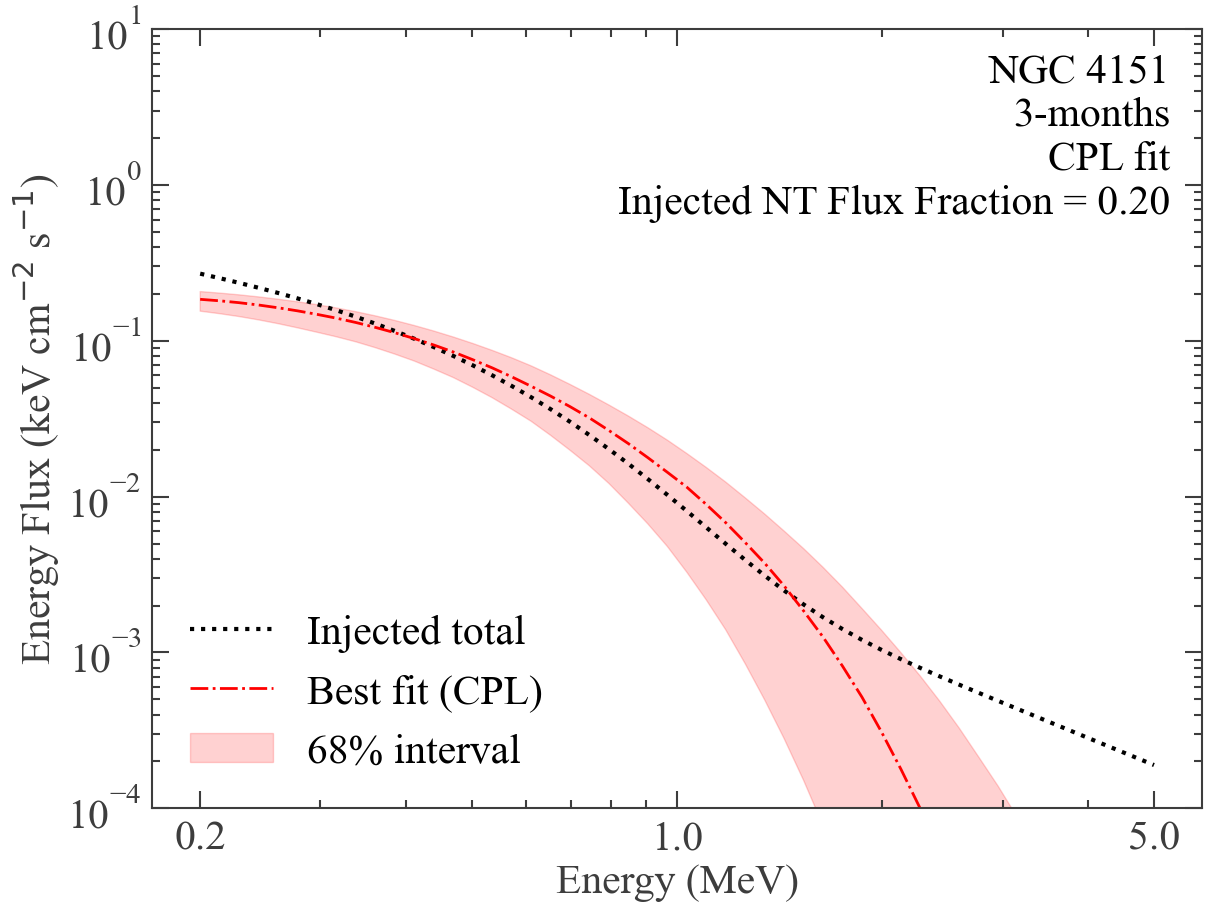

In [14]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
# Reset these explicitly because rcParams persist within a notebook kernel.
plt.rcParams.update({
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected total",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label=f"Best fit ({fit_model_label})",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 10)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

thermal_flux = np.asarray([spectrum_inj_cpl.evaluate_at(e) for e in energy])
tail_flux = np.asarray([spectrum_inj_tail.evaluate_at(e) for e in energy])
thermal_energy_flux = np.trapezoid(energy * thermal_flux, energy)
tail_energy_flux = np.trapezoid(energy * tail_flux, energy)
energy_flux_ratio = tail_energy_flux / (thermal_energy_flux + tail_energy_flux)

ax.text(
    0.97,
    0.97,
    (
        f"NGC 4151\n{exposure_months}-months\n"
        f"{fit_model_label} fit\n"
        f"Injected NT Flux Fraction = {energy_flux_ratio:.2f}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="normal",
)
ax.legend(fontsize=FONT_SIZE, loc="lower left", frameon=False)
plt.show()

Plot the forward-folded 21-source catalog plus the fitted instrumental
background against the constructed observed counts
(`total background + 21 binned source files`).

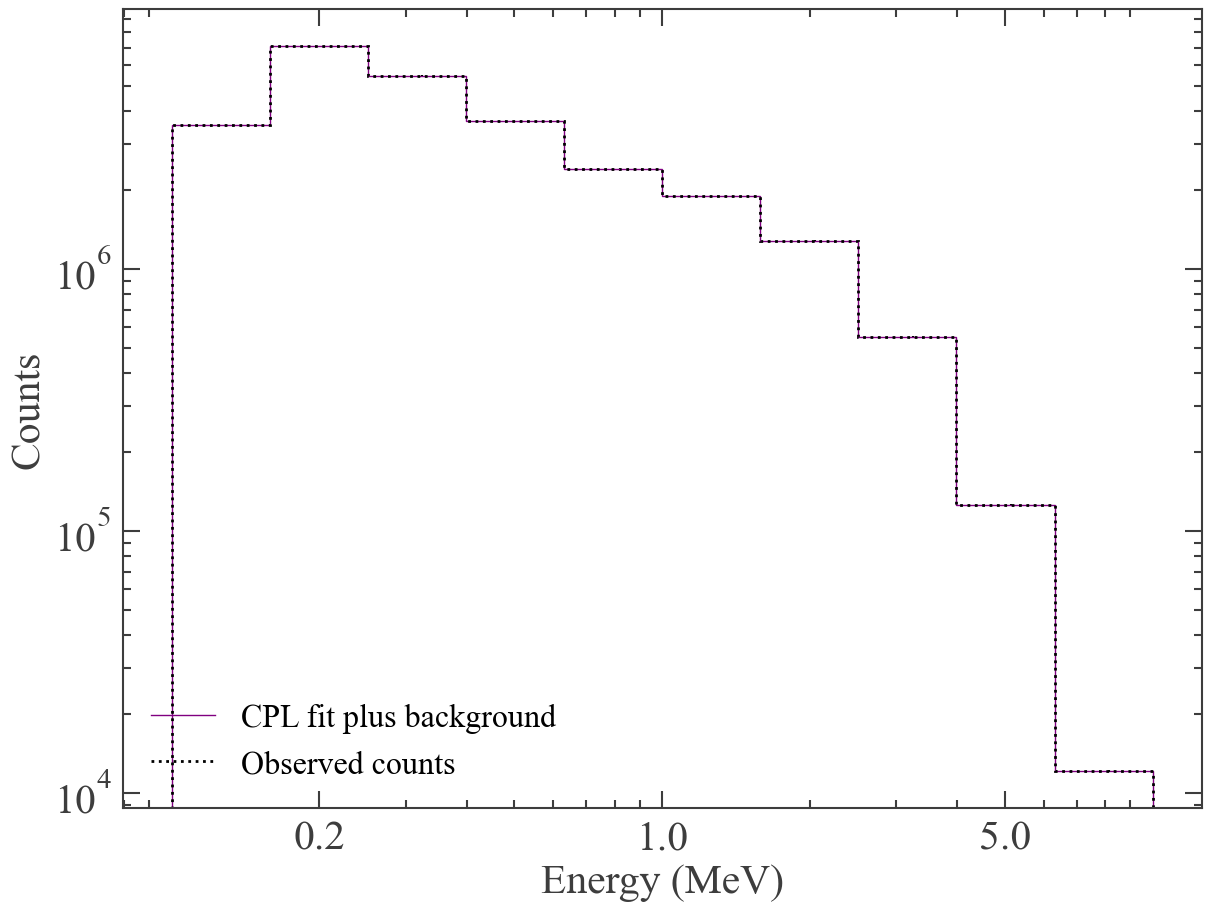

In [15]:
expectation_bkg = bkg.expectation(copy=True)
model_counts = (
    expectation.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(
    model_counts,
    binned_energy_edges / 1000,
    color="purple",
    label=f"{fit_model_label} fit plus background",
)
ax.errorbar(
    binned_energy / 1000,
    model_counts,
    yerr=np.sqrt(model_counts),
    color="purple",
    linewidth=0,
    elinewidth=1.5,
)
ax.stairs(
    data_counts,
    binned_energy_edges / 1000,
    color="black",
    ls=":",
    lw=2,
    label="Observed counts",
)
ax.errorbar(
    binned_energy / 1000,
    data_counts,
    yerr=np.sqrt(data_counts),
    color="black",
    linewidth=0,
    elinewidth=1.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()